# Paper 01 — Ghanem, Sant'Anna & Wüthrich: *Selection and Parallel Trends*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/did/01-ghanem-santanna-wuthrich-selection-parallel-trends/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is the runnable companion.

**What this simulation shows.** Parallel trends (PT) is a restriction on *how units select into treatment*, not a statement about trends alone. We run two scenarios with the same constant treatment effect:

- **Scenario A** — selection on time-invariant levels only (the gain-driving factor is independent of the untreated trend). PT holds, and the 2×2 DiD estimator recovers the true ATT on average.
- **Scenario B** — Roy-style selection on expected gains, where the gain-driving factor *does* correlate with the untreated trend. PT silently fails, and 2×2 DiD is biased even though the per-unit treatment effect is constant.

The punchline: selection-on-gains alone does not break DiD. Selection on a gain-driving factor that also moves the untreated trend does.

In [1]:
# On Colab: Runtime > Change runtime type > R (if not already on R).
# The base R install is enough — tidyverse ships with Colab's R runtime.
# Locally: any R >= 4.3 with tidyverse installed.

suppressPackageStartupMessages({
  library(tidyverse)
})

set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep='.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))
cat(sprintf('ggplot2    %s\n', packageVersion('ggplot2')))

R          4.5.3
tidyverse  2.0.0
ggplot2    4.0.2


## Parameters

Tunable constants. `N_SIM` controls Monte Carlo draws — drop to 50 for quick iteration.

In [2]:
N_SIM  <- 300    # Monte Carlo draws per scenario
N      <- 2000   # Units per draw
TAU    <- 1.5    # True per-unit gain base. With v ~ N(0,1) this implies
                 # P(D=1) ~ Phi(1.5) ~ 0.93 — an intentionally imbalanced
                 # split that magnifies the Roy-selection bias.
LAMBDA <- 1.0    # Spread of individual gains around TAU
GAMMA  <- 0.8    # Common time effect in Y(0,t=2) - Y(0,t=1)
SIGMA  <- 0.5    # Idiosyncratic noise sd

## Data-generating process

`rho` controls the correlation between the gain-driving unobserved $v$ and the untreated trend in period 2. `rho = 0` ⇒ PT holds; `rho > 0` ⇒ Roy selection silently breaks PT because treated units (high $v$) also have a steeper untreated trend.

The bias is the product of two things: $\rho > 0$ ties the untreated trend to $v$, AND treatment selects on $v$. Remove either ingredient and DiD is unbiased.

In [3]:
draw_dgp <- function(rho) {
  alpha <- rnorm(N, 0, 1)       # unit-level heterogeneity (level)
  v     <- rnorm(N, 0, 1)       # drives individual treatment gain
  eps1  <- rnorm(N, 0, SIGMA)   # period-1 noise
  eps2  <- rnorm(N, 0, SIGMA)   # period-2 noise

  y0_t1 <- alpha + eps1
  y0_t2 <- alpha + GAMMA + rho * v + eps2

  gain  <- TAU + LAMBDA * v
  y1_t2 <- y0_t2 + gain

  # Roy-style selection: treat if expected gain (plus mild noise) is positive.
  D     <- as.integer(gain + rnorm(N, 0, 0.3) > 0)

  y_t1  <- y0_t1
  y_t2  <- ifelse(D == 1, y1_t2, y0_t2)

  tibble(
    id     = seq_len(N),
    D      = D,
    gain   = gain,
    y_t1   = y_t1,
    y_t2   = y_t2,
    y0_t1  = y0_t1,
    y0_t2  = y0_t2
  )
}

run_once <- function(rho) {
  dgp <- draw_dgp(rho)
  att_true <- mean(dgp$gain[dgp$D == 1])

  df <- tibble(
    id     = rep(dgp$id, 2),
    period = c(rep(1L, N), rep(2L, N)),
    post   = as.integer(c(rep(0L, N), rep(1L, N))),
    treat  = rep(dgp$D, 2),
    y      = c(dgp$y_t1, dgp$y_t2)
  )

  fit <- lm(y ~ treat * post, data = df)
  dd  <- unname(coef(fit)['treat:post'])

  c(att_true = att_true, dd = dd, bias = dd - att_true)
}

## Monte Carlo

In [4]:
cat('Running Scenario A (PT holds, rho = 0) ... ')
A <- replicate(N_SIM, run_once(rho = 0.0))
cat('done.\n')

cat('Running Scenario B (Roy selection, rho = 1) ... ')
B <- replicate(N_SIM, run_once(rho = 1.0))
cat('done.\n\n')

summary_tbl <- tibble(
  scenario          = c('A: PT holds (rho=0)', 'B: Roy selection (rho=1)'),
  mean_true_ATT     = c(mean(A['att_true', ]), mean(B['att_true', ])),
  mean_DiD_estimate = c(mean(A['dd', ]),       mean(B['dd', ])),
  mean_bias         = c(mean(A['bias', ]),     mean(B['bias', ])),
  sd_DiD            = c(sd(A['dd', ]),         sd(B['dd', ]))
)

cat(sprintf('Monte Carlo summary (%d draws, N = %d per draw):\n', N_SIM, N))
print(summary_tbl, n = Inf)

Running Scenario A (PT holds, rho = 0) ... done.
Running Scenario B (Roy selection, rho = 1) ... done.

Monte Carlo summary (300 draws, N = 2000 per draw):
# A tibble: 2 × 5
  scenario                 mean_true_ATT mean_DiD_estimate mean_bias sd_DiD
  <chr>                            <dbl>             <dbl>     <dbl>  <dbl>
1 A: PT holds (rho=0)               1.65              1.64  -0.00249 0.0645
2 B: Roy selection (rho=1)          1.65              3.60   1.95    0.0807


## Diagnostic plot

Group-period means in one representative draw per scenario. The dashed line shows the treated group's counterfactual $Y(0)$ trend. In Scenario A it is parallel to the control trend; in Scenario B the counterfactual is *steeper* than the control trend, which is exactly what PT rules out.

The Monte Carlo loops above consumed an `N_SIM`-dependent amount of RNG state, so we re-anchor the seed here to keep the plot reproducible across different `N_SIM` values.

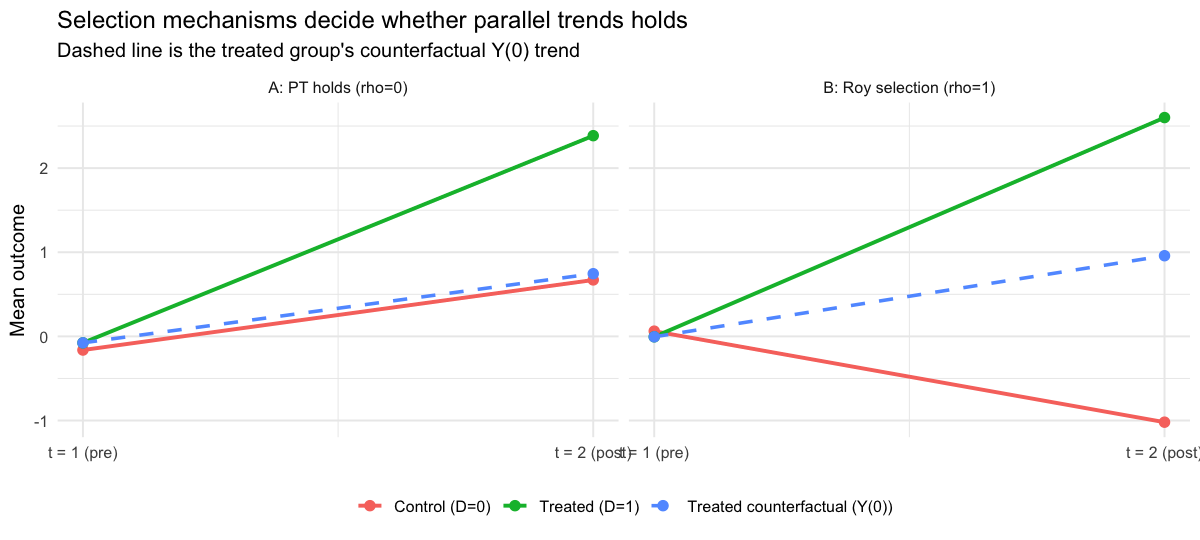

In [5]:
set.seed(20260421)  # re-anchor for reproducible plot

draw_for_plot <- function(rho, label) {
  dgp <- draw_dgp(rho)
  tibble(
    scenario = label,
    period   = rep(c(1, 2), each = N),
    D        = rep(dgp$D, 2),
    y        = c(dgp$y_t1, dgp$y_t2),
    y0       = c(dgp$y0_t1, dgp$y0_t2)
  )
}

plot_df <- bind_rows(
  draw_for_plot(0.0, 'A: PT holds (rho=0)'),
  draw_for_plot(1.0, 'B: Roy selection (rho=1)')
)

group_means <- plot_df |>
  group_by(scenario, period, D) |>
  summarise(y_mean = mean(y), y0_mean = mean(y0), .groups = 'drop') |>
  mutate(group = ifelse(D == 1, 'Treated (D=1)', 'Control (D=0)'))

treat_cf <- plot_df |>
  filter(D == 1) |>
  group_by(scenario, period) |>
  summarise(y0_mean = mean(y0), .groups = 'drop') |>
  mutate(group = 'Treated counterfactual (Y(0))')

options(repr.plot.width = 10, repr.plot.height = 4.5)

ggplot(group_means, aes(x = period, y = y_mean, colour = group)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2.5) +
  geom_line(
    data = treat_cf,
    aes(x = period, y = y0_mean, colour = group),
    linewidth = 1.0, linetype = 'dashed'
  ) +
  geom_point(data = treat_cf, aes(x = period, y = y0_mean, colour = group), size = 2.5) +
  scale_x_continuous(breaks = c(1, 2), labels = c('t = 1 (pre)', 't = 2 (post)')) +
  facet_wrap(~ scenario, ncol = 2) +
  labs(
    title = 'Selection mechanisms decide whether parallel trends holds',
    subtitle = 'Dashed line is the treated group\'s counterfactual Y(0) trend',
    x = NULL, y = 'Mean outcome', colour = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'bottom')

## Punchline

- **Scenario A.** DiD is ~unbiased. Selection on gains is present in both scenarios, but with $\rho = 0$ the gain-driving factor is independent of the untreated trend, so parallel trends still holds.
- **Scenario B.** DiD is systematically biased. The bias is the *product* of two things:
  1. $\rho > 0$ ties the untreated trend to the gain-driving factor $v$.
  2. Treatment selects units with high $v$.

Remove either ingredient and DiD is unbiased. Ghanem, Sant'Anna & Wüthrich's contribution is to make that joint dependence explicit: PT is a restriction on *how units select into treatment*, not a statement about trends in isolation.